In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Pass-Fail Data.csv")

In [3]:
df.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0


In [4]:
df.isnull().sum()

student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64

In [5]:
df.describe
df.shape

(100, 6)

# EDA : Exploratory Data Analysis

Text(0.5, 1.0, 'student will pass or not')

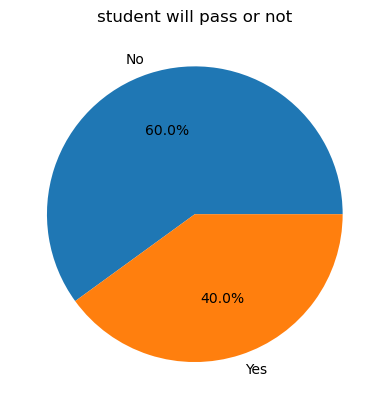

In [6]:
# how balanced are classess and categories:
class_count = df["pass"].value_counts()
plt.pie(class_count,labels = ["No","Yes"],autopct = "%1.1f%%")
plt.title("student will pass or not")

<Axes: xlabel='midterm_score', ylabel='Count'>

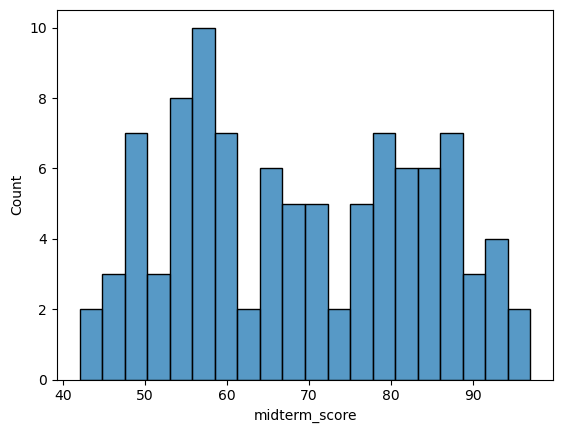

In [7]:
# How many number of students ranges between different midterm_score.
sns.histplot(
    data = df,
    x = "midterm_score",
    bins = 20
)

<Axes: xlabel='study_hours_per_week', ylabel='Count'>

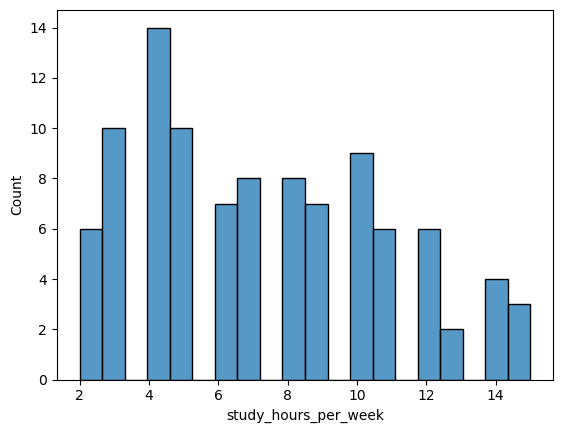

In [8]:
# How many number of students ranges between study_hours_per_week.
sns.histplot(
    data = df ,
    x = "study_hours_per_week",
    bins = 20
)

<Axes: xlabel='homework_pct', ylabel='Count'>

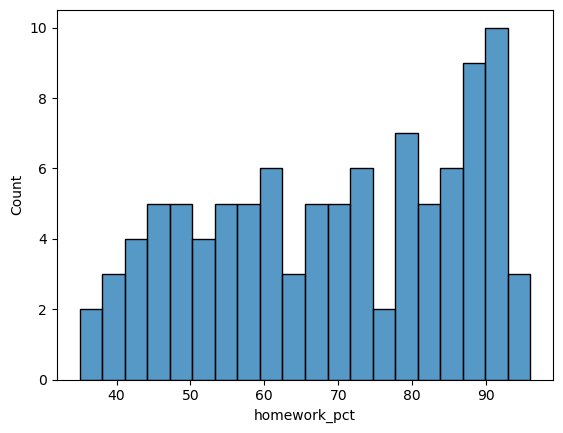

In [9]:
# how many number of students ranges between homework_pct 
sns.histplot(
    data = df,
    x = "homework_pct",
    bins = 20
)

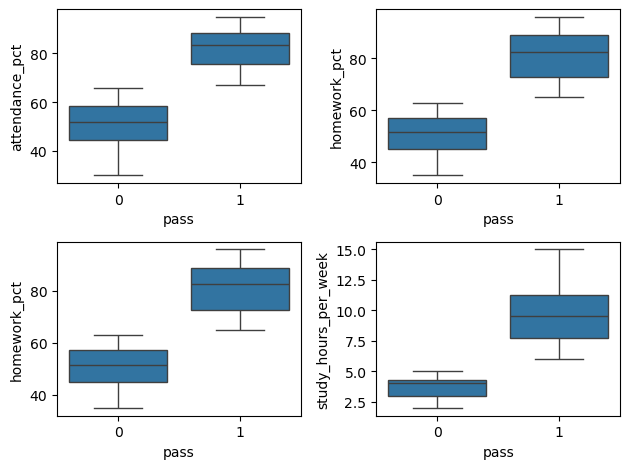

In [10]:
# outlier detection:=>
fig,axes = plt.subplots(2,2)
sns.boxplot(ax = axes[0,0],data = df ,x = "pass", y = "attendance_pct")
sns.boxplot(ax = axes[0,1] ,data = df,x = "pass" , y = "homework_pct")
sns.boxplot(ax = axes[1,0], data = df,x = "pass", y ="homework_pct")
sns.boxplot(ax = axes[1,1], data = df,x = "pass",y = "study_hours_per_week")
plt.tight_layout()


# Correlation Heatmap :

In [11]:
nums_cols = df.select_dtypes(include = "number")
corr_matrix = nums_cols.corr()

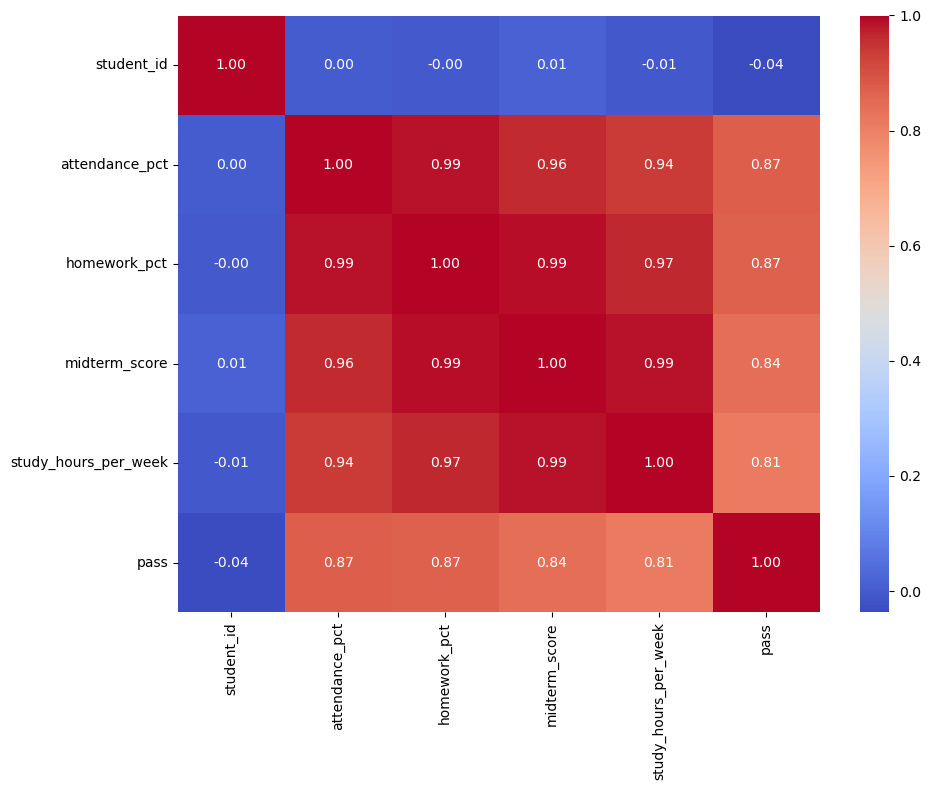

In [12]:
corr_matrix
plt.figure(figsize = (10,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)
plt.tight_layout()


In [14]:
nums_cols.corr()["pass"].sort_values(ascending = False)

pass                    1.000000
attendance_pct          0.873757
homework_pct            0.869662
midterm_score           0.839442
study_hours_per_week    0.811285
student_id             -0.036771
Name: pass, dtype: float64

# Feature Engineering :

In [15]:
# New features :
# performance_score:
df["performance_score"] = (df["attendance_pct"]+df["homework_pct"]+df["midterm_score"])/3
# Effort_score:
df["effort_score"] = (df["attendance_pct"]+df["study_hours_per_week"]*10)/2
# Homework_study_ratio
df["homework_study_ratio"] = (df["homework_pct"]/df["study_hours_per_week"])


# Train-Test-Split

In [27]:
X = df.drop(columns = ["pass","performance_score","effort_score","homework_study_ratio"])
Y = df["pass"]

In [28]:
X.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week
0,1,95,92,88,12
1,2,88,85,79,10
2,3,60,55,58,4
3,4,72,70,65,6
4,5,40,45,50,3


In [29]:
Y.head()

0    1
1    1
2    0
3    1
4    0
Name: pass, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size = 0.2,random_state = 42)

In [31]:
X_train

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week
55,56,63,62,59,5
88,89,69,67,65,6
26,27,48,45,50,3
42,43,75,72,70,7
69,70,70,67,65,6
...,...,...,...,...,...
60,61,92,91,89,13
71,72,83,80,78,9
14,15,92,95,93,15
92,93,60,58,56,4


In [32]:
X_test

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week
83,84,78,75,73,8
53,54,77,73,71,8
70,71,34,39,44,2
45,46,64,61,60,5
44,45,93,94,95,15
39,40,69,66,64,6
22,23,35,40,48,2
80,81,56,54,56,4
10,11,30,35,42,2
0,1,95,92,88,12


In [33]:
#logistic regression
from sklearn.linear_model import LogisticRegression
le = LogisticRegression()
model = le.fit(X_train,Y_train)
Y_predict = model.predict(X_test)
Y_predict
Y_test
# Evaluation 
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score 
print("Logistic_Regression")
print("accuracy_score:", accuracy_score(Y_test,Y_predict))
print("precision_score:", precision_score(Y_test,Y_predict))
print("recall_score:", recall_score(Y_test,Y_predict))
print("f1_score:",f1_score(Y_test,Y_predict))
print("confusion_matrix:",confusion_matrix(Y_test,Y_predict))

Logistic_Regression
accuracy_score: 1.0
precision_score: 1.0
recall_score: 1.0
f1_score: 1.0
confusion_matrix: [[ 8  0]
 [ 0 12]]


In [24]:
# naive bayes theorem :
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model_1 = model.fit(X_train,Y_train)
Y_predict = model_1.predict(X_test)
Y_predict
Y_test
# Evaluation
from sklearn.metrics import  confusion_matrix , accuracy_score,precision_score,recall_score,f1_score
print("naive_bayes")
print("accuracy_score:", accuracy_score(Y_test,Y_predict))
print("precision_score:",precision_score(Y_test,Y_predict))
print("recall_score:", recall_score(Y_test,Y_predict))
print("F1_score:", f1_score(Y_test,Y_predict))
print("confusion_matrix:",confusion_matrix(Y_test,Y_predict))

naive_bayes
accuracy_score: 1.0
precision_score: 1.0
recall_score: 1.0
F1_score: 1.0
confusion_matrix: [[ 8  0]
 [ 0 12]]


In [25]:
# KNN = K nearest neighbors
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
model = knn.fit(X_train,Y_train)
model
Y_predict = model.predict(X_test)
Y_predict
Y_test
# Evaluation
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score
print("KNN")
print("accuracy_score:", accuracy_score(Y_test,Y_predict))
print("precision_score:", precision_score(Y_test,Y_predict))
print("f1_score:", f1_score(Y_test,Y_predict))
print("recall_score:", recall_score(Y_test,Y_predict))

KNN
accuracy_score: 1.0
precision_score: 1.0
f1_score: 1.0
recall_score: 1.0
